# Method results

Per-method report card. Pick one `METHOD` in the first cell; everything below runs for that method only.

Sections:
1. Simulation results
2. Classifier results
3. Stability diagnostics from resampling
4. Final protein list + enrichment

In [1]:
METHOD = "ttest"   # change this to switch the whole notebook

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.styles.colors import CATEGORICAL, PALETTE, SEQUENTIAL_TEAL, SEQUENTIAL_ORANGE

sns.set_theme(style="whitegrid", context="notebook")

RESULTS = REPO_ROOT / "results"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"

STAGE_DIRS = {
    "simulation": RESULTS / "simulation" / METHOD,
    "classifier": RESULTS / "classifier" / METHOD,
    "selection":  RESULTS / "selection" / METHOD,
    "enrichment": RESULTS / "enrichment" / METHOD,
}
missing = [s for s, p in STAGE_DIRS.items() if not p.exists()]
assert not missing, f"Missing result directories for METHOD={METHOD!r}: {missing}"

def load_meta(path: Path) -> dict:
    with open(path) as f:
        return json.load(f)

print(f"METHOD = {METHOD}")
for stage, path in STAGE_DIRS.items():
    print(f"  {stage:<10s} -> {path.relative_to(REPO_ROOT)}")

METHOD = ttest
  simulation -> results/simulation/ttest
  classifier -> results/classifier/ttest
  selection  -> results/selection/ttest
  enrichment -> results/enrichment/ttest


In [2]:
sel_meta = load_meta(STAGE_DIRS["selection"] / "meta.json")
full_meta = load_meta(STAGE_DIRS["selection"] / "full_data_meta.json")
sim_meta = load_meta(STAGE_DIRS["simulation"] / "meta.json")
clf_meta = load_meta(STAGE_DIRS["classifier"] / "meta.json")

header = pd.DataFrame({
    "stage":   ["selection (resampling)", "selection (full data)", "simulation", "classifier"],
    "n_samples":   [sel_meta.get("n_samples"),  full_meta.get("n_samples"),  sim_meta.get("n_samples"),  clf_meta.get("n_samples")],
    "n_proteins":  [sel_meta.get("n_proteins"), full_meta.get("n_proteins"), sim_meta.get("n_proteins"), clf_meta.get("n_proteins")],
    "n_splits":    [sel_meta.get("n_splits"),   None,                         None,                        clf_meta.get("n_splits")],
    "n_significant": [sel_meta.get("method_params", {}).get("n_significant"),
                      full_meta.get("n_significant"),
                      None,
                      None],
    "seed":        [sel_meta.get("seed"), full_meta.get("seed"), sim_meta.get("seed"), clf_meta.get("seed")],
})
header

,stage,n_samples,n_proteins,n_splits,n_significant,seed
0,selection (resampling),512.0,10776.0,50.0,NaN,42
1,selection (full data),512.0,10776.0,NaN,12.0,42
2,simulation,400.0,NaN,NaN,NaN,42
3,classifier,NaN,NaN,50.0,NaN,42


## 1. Simulation results

Synthetic-signal recovery under controlled effect sizes. Higher `recall` at fixed `k` is better; lower `fdr` is better.

In [3]:
recall_df = pd.read_parquet(STAGE_DIRS["simulation"] / "recall.parquet")
fdr_df = pd.read_parquet(STAGE_DIRS["simulation"] / "fdr.parquet")
print(
    f"recall: {len(recall_df):,} rows | repeats={recall_df['repeat'].nunique()} | "
    f"signal_types={sorted(recall_df['signal_type'].unique())} | "
    f"effect_sizes={sorted(recall_df['effect_size'].unique())} | k={sorted(recall_df['k'].unique())}"
)
print(
    f"fdr:    {len(fdr_df):,} rows | repeats={fdr_df['repeat'].nunique()} | k={sorted(fdr_df['k'].unique())}"
)
recall_df.head(10)

recall: 3,750 rows | repeats=50 | signal_types=['linear', 'saturation', 'threshold', 'u_shape', 'xor_pair'] | effect_sizes=[np.float64(0.3), np.float64(0.6), np.float64(1.0)] | k=['10', '100', '25', '50', 'native']
fdr:    250 rows | repeats=50 | k=['10', '100', '25', '50', 'native']


,repeat,signal_type,effect_size,k,recall
0,1,linear,0.3,10,0.000000
1,1,linear,0.3,100,1.000000
2,1,linear,0.3,25,0.333333
3,1,linear,0.3,50,1.000000
4,1,linear,0.3,native,0.666667
5,1,linear,0.6,10,0.000000
6,1,linear,0.6,100,1.000000
7,1,linear,0.6,25,1.000000
8,1,linear,0.6,50,1.000000
9,1,linear,0.6,native,1.000000


In [4]:
recall_summary = (
    recall_df.groupby(["signal_type", "effect_size", "k"], as_index=False)
       .agg(recall_mean=("recall", "mean"), recall_std=("recall", "std"),
            n=("recall", "size"))
)
recall_summary.round(3)

,signal_type,effect_size,k,recall_mean,recall_std,n
0,linear,0.3,10,0.000,0.000,50
1,linear,0.3,100,1.000,0.000,50
2,linear,0.3,25,0.607,0.306,50
3,linear,0.3,50,0.953,0.135,50
4,linear,0.3,native,0.453,0.321,50
...,...,...,...,...,...,...
70,xor_pair,1.0,10,0.000,0.000,50
71,xor_pair,1.0,100,1.000,0.000,50
72,xor_pair,1.0,25,0.017,0.051,50
73,xor_pair,1.0,50,0.343,0.189,50


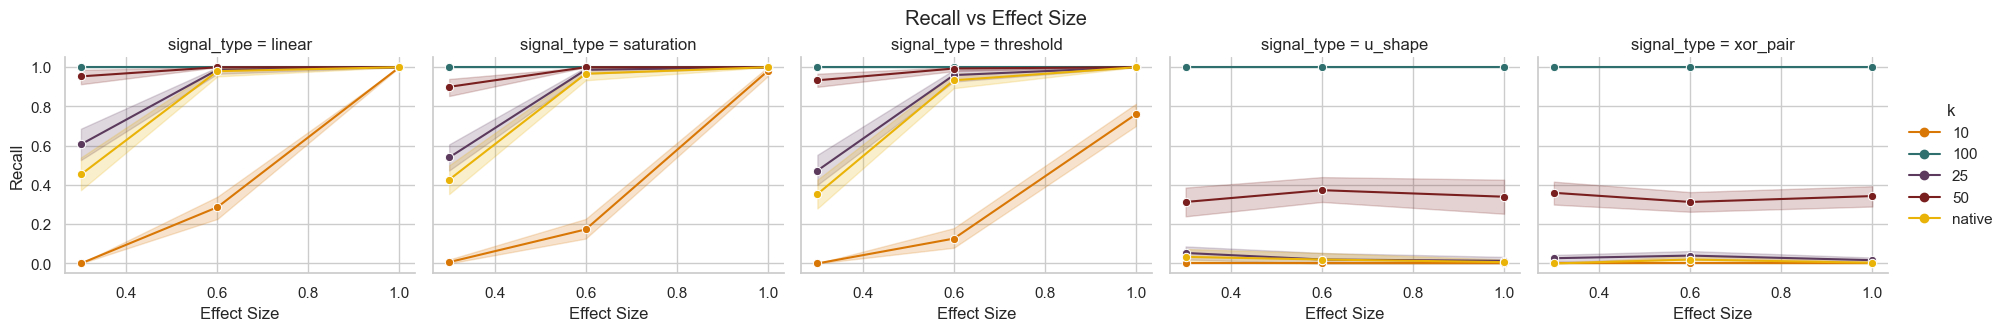

In [5]:
k_values = sorted(recall_df["k"].unique())
palette_k = dict(zip(k_values, CATEGORICAL[:len(k_values)]))

g = sns.relplot(
    data=recall_df, kind="line",
    x="effect_size", y="recall", hue="k", col="signal_type",
    palette=palette_k, marker="o", errorbar=("ci", 95), height=3.2, aspect=1.2,
    facet_kws={"sharey": True},
)
g.set_axis_labels("Effect Size", "Recall")
g.fig.suptitle(f"Recall vs Effect Size", y=1.03)
plt.show()

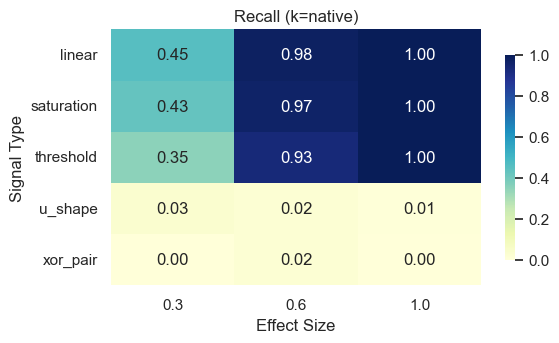

In [6]:
native_k = max(recall_df["k"].unique())
sim_native = recall_df[recall_df["k"] == native_k]

fig, ax = plt.subplots(figsize=(6, 3.6))
pivot = (
    sim_native.groupby(["signal_type", "effect_size"])["recall"].mean()
    .unstack("effect_size")
)
sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="YlGnBu",
    ax=ax, vmin=0, vmax=1, cbar_kws={"shrink": 0.8}
 )
ax.set_title(f"Recall (k={native_k})")
ax.set_xlabel("Effect Size")
ax.set_ylabel("Signal Type")
fig.tight_layout()
plt.show()

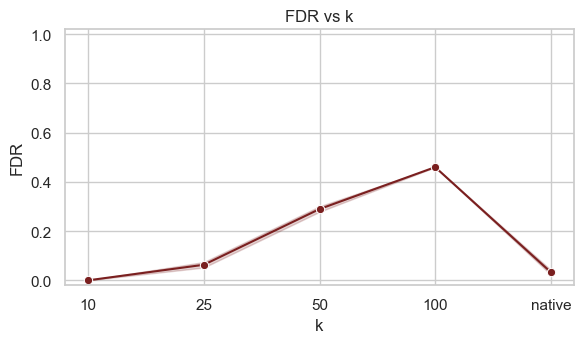

,k,fdr_mean,fdr_std,n_selected_mean
0,10,0.000,0.000,10.00
1,25,0.063,0.043,25.00
2,50,0.290,0.041,50.00
3,100,0.460,0.000,100.00
4,native,0.033,0.037,22.44


In [7]:
# FDR is per (repeat, k) — one independent observation per repeat. CIs reflect 50 reps, not 750 duplicates.
def _k_sort_key(value):
    s = str(value).strip().lower()
    if s == "native":
        return (2, float("inf"))
    try:
        return (0, float(s))
    except ValueError:
        return (1, s)

k_order = sorted(pd.unique(fdr_df["k"]), key=_k_sort_key)

fdr_plot = fdr_df.copy()
fdr_plot["k"] = pd.Categorical(fdr_plot["k"], categories=k_order, ordered=True)
fdr_plot = fdr_plot.sort_values("k")

fig, ax = plt.subplots(figsize=(6, 3.6))
sns.lineplot(
    data=fdr_plot, x="k", y="fdr", estimator="mean", errorbar=("ci", 95),
    marker="o", color=PALETTE["danger"], ax=ax,
)
ax.set_title(f"FDR vs k")
ax.set_xlabel("k")
ax.set_ylabel("FDR")
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
plt.show()

(
    fdr_plot.groupby("k", as_index=False, sort=False, observed=True)
    .agg(fdr_mean=("fdr", "mean"), fdr_std=("fdr", "std"),
         n_selected_mean=("n_selected", "mean"))
    .round(3)
)

## 2. Classifier results

Downstream classifier performance when trained on the top-k features selected by this method on each resampled split.

In [8]:
clf = pd.read_parquet(STAGE_DIRS["classifier"] / "scores.parquet")
print(f"{len(clf):,} rows | splits={clf['split_id'].nunique()} | classifiers={sorted(clf['classifier'].unique())} | "
      f"k={sorted(clf['k'].unique())}")
clf.head()

750 rows | splits=50 | classifiers=['LogisticRegression', 'RandomForest', 'XGBoost'] | k=['10', '100', '25', '50', 'native']


,split_id,classifier,k,auc,aupr,n_features_actual
0,0,LogisticRegression,10,0.517424,0.200761,10
1,0,RandomForest,10,0.398485,0.122738,10
2,0,XGBoost,10,0.465909,0.139887,10
3,0,LogisticRegression,25,0.585606,0.245516,25
4,0,RandomForest,25,0.556818,0.221864,25


In [9]:
clf_summary = (
    clf.groupby(["classifier", "k"], as_index=False)
       .agg(auc_mean=("auc", "mean"), auc_std=("auc", "std"),
            aupr_mean=("aupr", "mean"), aupr_std=("aupr", "std"),
            n=("auc", "size"))
       .sort_values(["classifier", "k"])
)
clf_summary.round(3).style.background_gradient(subset=["auc_mean", "aupr_mean"], cmap="YlGnBu")

,classifier,k,auc_mean,auc_std,aupr_mean,aupr_std,n
0,LogisticRegression,10,0.567000,0.067000,0.208000,0.057000,50
1,LogisticRegression,100,0.638000,0.065000,0.254000,0.065000,50
2,LogisticRegression,25,0.592000,0.079000,0.223000,0.063000,50
3,LogisticRegression,50,0.613000,0.067000,0.240000,0.063000,50
4,LogisticRegression,native,0.559000,0.054000,0.194000,0.038000,50
5,RandomForest,10,0.567000,0.070000,0.199000,0.047000,50
6,RandomForest,100,0.618000,0.072000,0.231000,0.062000,50
7,RandomForest,25,0.587000,0.072000,0.220000,0.064000,50
8,RandomForest,50,0.592000,0.070000,0.216000,0.056000,50
9,RandomForest,native,0.537000,0.067000,0.187000,0.048000,50


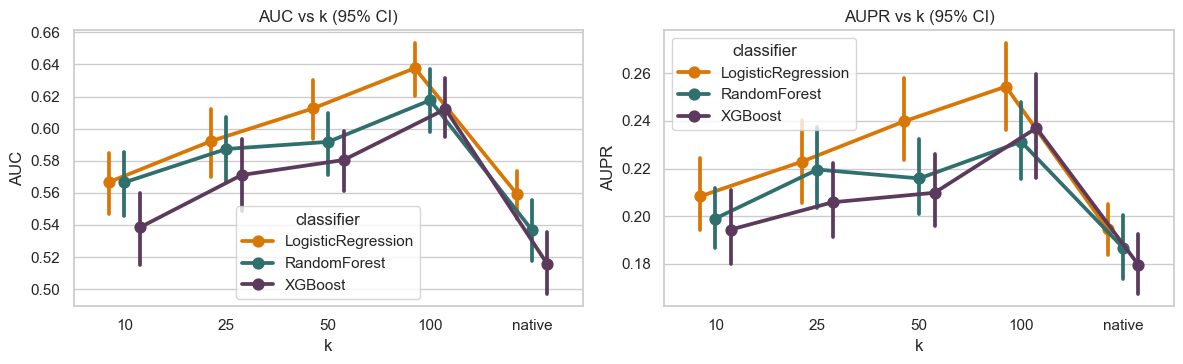

In [10]:
classifier_order = sorted(clf["classifier"].unique())
palette_clf = dict(zip(classifier_order, CATEGORICAL[:len(classifier_order)]))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, metric, ylabel in [(axes[0], "auc", "AUC"), (axes[1], "aupr", "AUPR")]:
    sns.pointplot(data=clf, x="k", y=metric, hue="classifier",
                  palette=palette_clf, errorbar=("ci", 95), dodge=0.3, ax=ax)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs k (95% CI)")
fig.tight_layout()
plt.show()

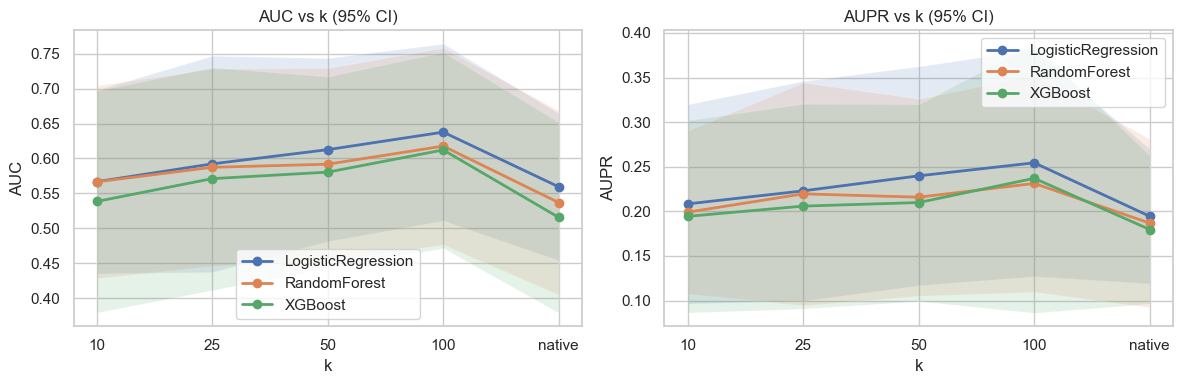

In [11]:
clf_agg = clf.groupby(["classifier", "k"]).agg(
    auc_mean=("auc", "mean"),
    auc_std=("auc", "std"),
    aupr_mean=("aupr", "mean"),
    aupr_std=("aupr", "std"),
).reset_index()

k_order = ["10", "25", "50", "100", "native"]
x_positions = list(range(len(k_order)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in [(axes[0], "auc", "AUC"), (axes[1], "aupr", "AUPR")]:
    for classifier, group in clf_agg.groupby("classifier"):
        group = group.copy()
        group["x"] = group["k"].map({k: i for i, k in enumerate(k_order)})
        group = group.sort_values("x")

        x = group["x"].values
        y = group[f"{metric}_mean"].values
        yerr = group[f"{metric}_std"].values

        ax.plot(x, y, marker="o", label=classifier, linewidth=2)
        ax.fill_between(x, y - 1.96 * yerr, y + 1.96 * yerr, alpha=0.15)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(k_order)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("k")
    ax.set_title(f"{ylabel} vs k (95% CI)")
    ax.legend()

fig.tight_layout()
plt.show()


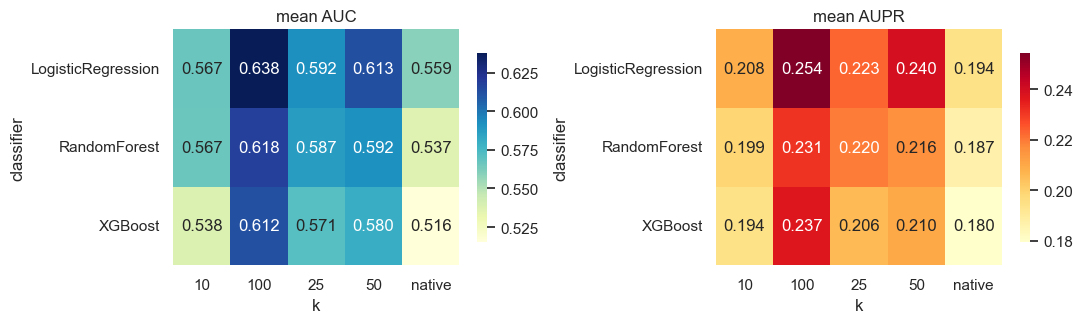

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, metric, cmap, title in [
    (axes[0], "auc",  "YlGnBu", "mean AUC"),
    (axes[1], "aupr", "YlOrRd", "mean AUPR"),
]:
    pivot = clf.groupby(["classifier", "k"])[metric].mean().unstack("k")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{title}")
fig.tight_layout()
plt.show()

## 3. Stability diagnostics

How often each protein was selected across the resampled splits.
- `stability_significant.parquet` â€” frequency under the significance-threshold rule
- `stability_topk.parquet` â€” frequency for k âˆˆ {10, 25, 50, 100}

At the end of this section we overlay the final protein list (from Section 4) on the stability curves, so you can see whether the final picks came from the stable tail or not.

In [13]:
stab_sig = pd.read_parquet(STAGE_DIRS["selection"] / "stability_significant.parquet")
stab_topk = pd.read_parquet(STAGE_DIRS["selection"] / "stability_topk.parquet")

# Final protein list is defined by full_data_ranking.significant and is used in Section 4 as well.
ranking = pd.read_parquet(STAGE_DIRS["selection"] / "full_data_ranking.parquet")
final_list = ranking[ranking["significant"]].sort_values("rank").reset_index(drop=True)
final_ids = set(final_list["protein_id"])

print(f"significant-rule: {len(stab_sig):,} proteins observed with frequency>0")
print(f"top-k:            {len(stab_topk):,} rows across k={sorted(stab_topk['k'].unique())}")
print(f"final list size:  {len(final_list)} proteins")

significant-rule: 10,776 proteins observed with frequency>0
top-k:            43,104 rows across k=[np.int64(10), np.int64(25), np.int64(50), np.int64(100)]
final list size:  12 proteins


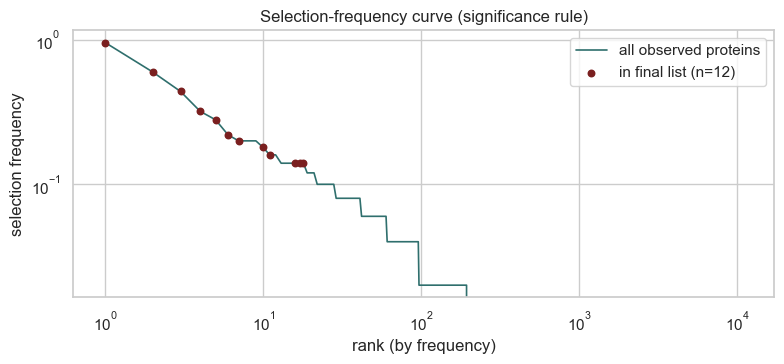

final-list proteins that appear in stability_significant: 12/12


In [14]:
curve = stab_sig.sort_values("frequency", ascending=False).reset_index(drop=True)
curve["rank"] = np.arange(1, len(curve) + 1)
curve["in_final_list"] = curve["protein_id"].isin(final_ids)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(curve["rank"], curve["frequency"], color=PALETTE["secondary"], lw=1.2, label="all observed proteins")
hit = curve[curve["in_final_list"]]
ax.scatter(hit["rank"], hit["frequency"], color=PALETTE["danger"], s=22, zorder=5,
           label=f"in final list (n={len(hit)})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("rank (by frequency)")
ax.set_ylabel("selection frequency")
ax.set_title(f"Selection-frequency curve (significance rule)")
ax.legend()
fig.tight_layout()
plt.show()

n_final_observed = curve["in_final_list"].sum()
print(f"final-list proteins that appear in stability_significant: {n_final_observed}/{len(final_list)}")

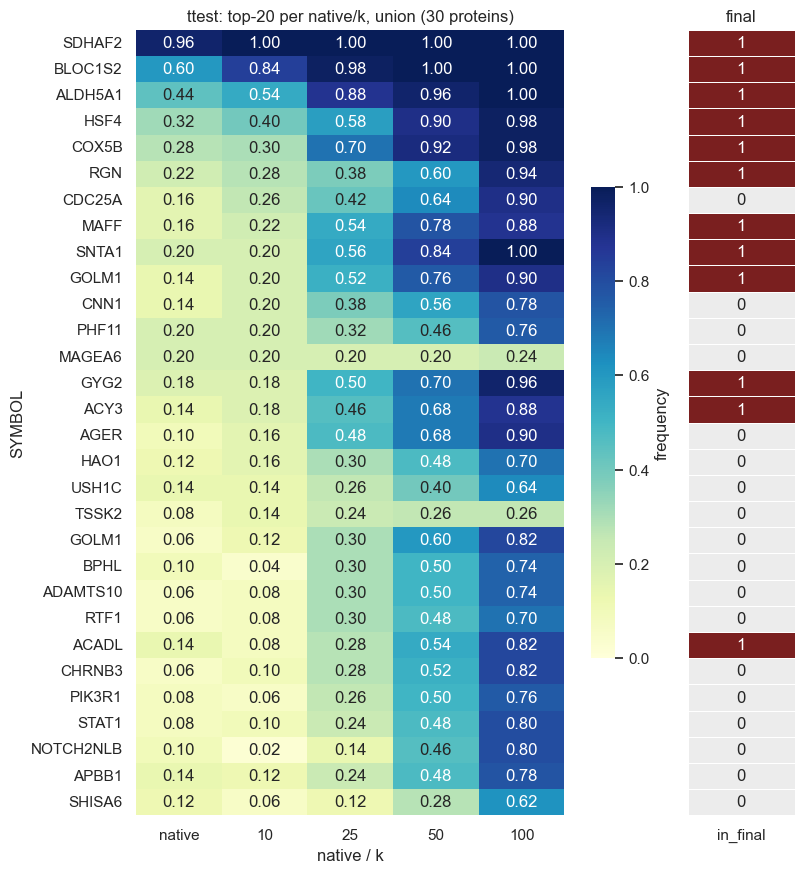

In [15]:
# Top-k/native frequency heatmap: union of the top-20 proteins at each k plus native,
# rows=proteins, cols=[native + k values], cells=frequency, with a final-list membership flag.
topN = 20
k_vals = sorted(stab_topk["k"].unique())
native_col = "native"

def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann_map = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv", usecols=["PROBEID", "SYMBOL"])
ann_map["probe_norm"] = ann_map["PROBEID"].map(_normalize_probe_id)
symbol_lookup = (
    ann_map.dropna(subset=["SYMBOL"])
.drop_duplicates("probe_norm")
.set_index("probe_norm")["SYMBOL"]
)

top_union_k = (
    stab_topk.sort_values(["k", "frequency"], ascending=[True, False])
.groupby("k").head(topN)["protein_id"].tolist()
)
top_union_native = (
    stab_sig.sort_values("frequency", ascending=False)
.head(topN)["protein_id"].tolist()
)
top_union = list(dict.fromkeys(top_union_k + top_union_native))

mat = (stab_topk[stab_topk["protein_id"].isin(top_union)]
.pivot_table(index="protein_id", columns="k", values="frequency", fill_value=0)
.reindex(top_union))
mat[native_col] = mat.index.to_series().map(stab_sig.set_index("protein_id")["frequency"]).fillna(0.0)
mat["in_final"] = mat.index.to_series().isin(final_ids).astype(int)

display_cols = [native_col] + k_vals
row_labels = [symbol_lookup.get(_normalize_probe_id(pid), pid) for pid in mat.index]
mat_display = mat.copy()
mat_display.index = row_labels

fig, (ax_hm, ax_flag) = plt.subplots(
    1, 2, figsize=(1.1 * len(display_cols) + 3, 0.3 * len(mat_display) + 1.2),
    gridspec_kw={"width_ratios": [len(display_cols), 1], "wspace": 0.05},
)
sns.heatmap(
    mat_display[display_cols],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=mat_display[display_cols].values.max(),
    ax=ax_hm,
    cbar_kws={"shrink": 0.6, "label": "frequency"},
)
ax_hm.set_title(f"{METHOD}: top-{topN} per native/k, union ({len(mat_display)} proteins)")
ax_hm.set_xlabel("native / k")
ax_hm.set_ylabel("SYMBOL")

sns.heatmap(
    mat_display[["in_final"]],
    annot=True,
    fmt="d",
    cmap=["#ECECEC", PALETTE["danger"]],
    cbar=False,
    ax=ax_flag,
    linewidths=0.4,
    linecolor="white",
)
ax_flag.set_yticks([])
ax_flag.set_xlabel("")
ax_flag.set_title("final")
plt.show()

In [16]:
thresholds = [0.1, 0.2, 0.3, 0.5]

sig_counts = {f"freq>={t}": int((stab_sig["frequency"] >= t).sum()) for t in thresholds}
topk_counts = (
    stab_topk.groupby("k")
             .apply(lambda g: pd.Series({f"freq>={t}": int((g["frequency"] >= t).sum()) for t in thresholds}))
)
summary = pd.concat(
    [pd.DataFrame([sig_counts], index=["significant"]), topk_counts.rename(lambda k: f"top-{k}")]
)
print("Proteins crossing frequency thresholds:")
display(summary)

print("\nmean_rank / mean_score (significant rule):")
display(stab_sig[["frequency", "mean_rank", "mean_score"]].describe().round(3))

Proteins crossing frequency thresholds:


/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_66549/2262248249.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({f"freq>={t}": int((g["frequency"] >= t).sum()) for t in thresholds}))


,freq>=0.1,freq>=0.2,freq>=0.3,freq>=0.5
significant,28,9,4,2
top-10,25,13,5,3
top-25,69,34,20,9
top-50,127,69,45,21
top-100,262,144,91,51



mean_rank / mean_score (significant rule):


,frequency,mean_rank,mean_score
count,10776.000,10776.000,10776.000
mean,0.001,5387.500,-0.000
std,0.015,2353.769,0.028
min,0.000,0.500,-0.171
25%,0.000,3587.755,-0.013
50%,0.000,5918.910,-0.001
75%,0.000,7492.035,0.013
max,0.960,8879.460,0.231


## 4. Final protein list and enrichment

The final list is `significant == True` in `full_data_ranking.parquet` â€” i.e. the method's selection when run on the full (non-resampled) cohort. Enrichment below is whatever was produced against that list.

In [17]:
def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv")
ann["probe_norm"] = ann["PROBEID"].map(_normalize_probe_id)

final = final_list.copy()
final["probe_norm"] = final["protein_id"].map(_normalize_probe_id)
final = final.merge(
    ann[["probe_norm", "SYMBOL", "UNIPROT", "GENENAME"]],
    on="probe_norm", how="left",
).drop(columns="probe_norm")

# Join resampling frequency so the reader sees how stable each final protein is.
final = final.merge(
    stab_sig[["protein_id", "frequency"]].rename(columns={"frequency": "resample_freq"}),
    on="protein_id", how="left",
)
final["resample_freq"] = final["resample_freq"].fillna(0.0)

print(f"{len(final)} final proteins | symbols mapped: {final['SYMBOL'].notna().sum()} | "
      f"mean resample frequency: {final['resample_freq'].mean():.3f}")
display(final[["rank", "protein_id", "SYMBOL", "GENENAME", "score", "q_value", "resample_freq"]]
        .round(4)
        .style.background_gradient(subset=["resample_freq"], cmap="YlGnBu"))

12 final proteins | symbols mapped: 12 | mean resample frequency: 0.315


,rank,protein_id,SYMBOL,GENENAME,score,q_value,resample_freq
0,0,seq.26103.20,SDHAF2,succinate dehydrogenase complex assembly factor 2,-0.065500,0.000200,0.960000
1,1,seq.21184.1,BLOC1S2,biogenesis of lysosomal organelles complex 1 subunit 2,-0.057700,0.009300,0.600000
2,2,seq.17792.158,ALDH5A1,aldehyde dehydrogenase 5 family member A1,-0.105700,0.019400,0.440000
3,3,seq.33451.35,HSF4,heat shock transcription factor 4,-0.039100,0.021100,0.320000
4,4,seq.7887.57,COX5B,cytochrome c oxidase subunit 5B,-0.038500,0.021200,0.280000
5,5,seq.21781.9,ACY3,aminoacylase 3,-0.111900,0.033900,0.140000
6,6,seq.23224.11,RGN,regucalcin,-0.050600,0.033900,0.220000
7,7,seq.22946.55,SNTA1,syntrophin alpha 1,-0.041100,0.033900,0.200000
8,8,seq.25066.32,GYG2,glycogenin 2,-0.037300,0.033900,0.180000
9,9,seq.17456.53,GOLM1,golgi membrane protein 1,0.135200,0.047800,0.140000


In [18]:
with open(STAGE_DIRS["enrichment"] / "gene_list.json") as f:
    gene_list = json.load(f)

print(f"source: {gene_list['source']}  min_size={gene_list['min_size']}  "
      f"n_proteins={gene_list['n_proteins']}  n_genes={gene_list['n_genes']}")

enrich_proteins = set(gene_list["protein_ids"])
only_final = enrich_proteins ^ set(final["protein_id"])
if only_final:
    print(f"NOTE: {len(only_final)} proteins differ between final list and enrichment input: {sorted(only_final)[:10]}")
else:
    print("Enrichment input matches the final list exactly.")

source: significant  min_size=10  n_proteins=12  n_genes=12
Enrichment input matches the final list exactly.


In [19]:
libraries = sorted(p.name for p in STAGE_DIRS["enrichment"].iterdir() if p.is_dir() and not p.name.startswith("_"))
print("enrichment libraries:", libraries)

rows = []
for lib in libraries:
    bes_path = STAGE_DIRS["enrichment"] / lib / "bes_components.json"
    if not bes_path.exists():
        print(f"[skip] {lib}: bes_components.json missing")
        continue
    bes = load_meta(bes_path)
    rows.append({
        "library": lib,
        "gene_list_size": bes.get("gene_list_size"),
        "background_size": bes.get("background_size"),
        "bes_raw": bes.get("bes_raw"),
        "bes_z":   bes.get("bes_z"),
        "bes_p_emp": bes.get("bes_p_emp"),
        "n_significant_terms": bes.get("bes_components", {}).get("n_significant_terms"),
        "n_terms_input":       bes.get("bes_components", {}).get("n_terms_input"),
    })
bes_df = pd.DataFrame(rows)
bes_df.round(3).style.background_gradient(subset=["bes_z"], cmap="YlGnBu")

enrichment libraries: ['GO_Biological_Process_2025', 'KEGG_2026', 'Reactome_Pathways_2024']


,library,gene_list_size,background_size,bes_raw,bes_z,bes_p_emp,n_significant_terms,n_terms_input
0,GO_Biological_Process_2025,12,9511,3.468000,-0.172000,0.194000,2,93
1,KEGG_2026,12,9511,0.000000,-0.197000,1.000000,0,24
2,Reactome_Pathways_2024,12,9511,0.000000,-0.110000,1.000000,0,42


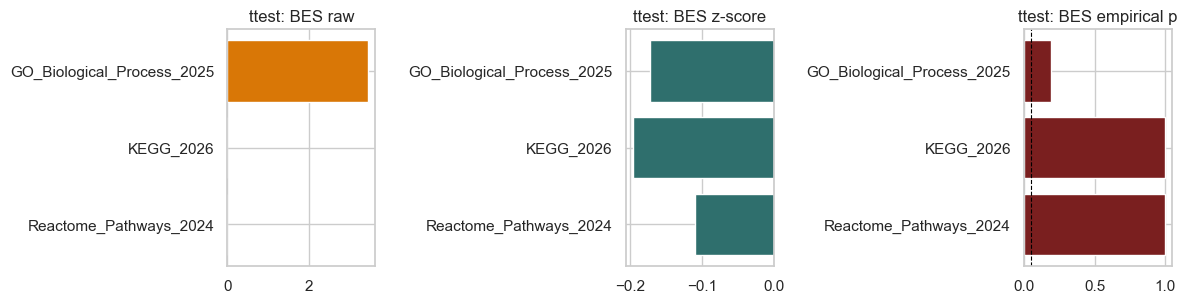

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (metric, color, title) in zip(axes, [
    ("bes_raw", PALETTE["primary"],  "BES raw"),
    ("bes_z",   PALETTE["secondary"], "BES z-score"),
    ("bes_p_emp", PALETTE["danger"], "BES empirical p"),
]):
    ax.barh(bes_df["library"], bes_df[metric], color=color)
    ax.set_title(f"{METHOD}: {title}")
    ax.invert_yaxis()
axes[2].axvline(0.05, color="black", ls="--", lw=0.8)
fig.tight_layout()
plt.show()

In [21]:
TOP_N_TERMS = 15
for lib in libraries:
    terms = pd.read_parquet(STAGE_DIRS["enrichment"] / lib / "terms.parquet")
    sig = terms[terms["q_value"] < 0.05].sort_values("q_value")
    print(f"\n### {lib}:  {len(sig)} terms q<0.05 (of {len(terms)})")
    show = (sig if len(sig) else terms.sort_values("q_value")).head(TOP_N_TERMS)
    display(show[["term", "q_value", "p_value", "overlap_size", "term_size", "genes"]].round(4))


### GO_Biological_Process_2025:  2 terms q<0.05 (of 93)


,term,q_value,p_value,overlap_size,term_size,genes
0,Aerobic Electron Transport Chain (GO:0019646),0.0184,0.0004,2,2,SDHAF2;COX5B
1,Mitochondrial ATP Synthesis Coupled Electron T...,0.0184,0.0004,2,2,SDHAF2;COX5B



### KEGG_2026:  0 terms q<0.05 (of 24)


,term,q_value,p_value,overlap_size,term_size,genes
0,BUTANOATE METABOLISM,0.1307,0.0175,1,1,ALDH5A1
12,DILATED CARDIOMYOPATHY,0.1307,0.0708,1,1,SNTA1
10,OXIDATIVE PHOSPHORYLATION,0.1307,0.0613,1,1,COX5B
9,VIRAL MYOCARDITIS,0.1307,0.0601,1,1,SNTA1
8,ARRHYTHMOGENIC RIGHT VENTRICULAR CARDIOMYOPATHY,0.1307,0.0601,1,1,SNTA1
7,PPAR SIGNALING PATHWAY,0.1307,0.0577,1,1,ACADL
11,HYPERTROPHIC CARDIOMYOPATHY,0.1307,0.0696,1,1,SNTA1
5,"ALANINE, ASPARTATE AND GLUTAMATE METABOLISM",0.1307,0.0348,1,1,ALDH5A1
4,FATTY ACID DEGRADATION,0.1307,0.0323,1,1,ACADL
3,STARCH AND SUCROSE METABOLISM,0.1307,0.0262,1,1,GYG2



### Reactome_Pathways_2024:  0 terms q<0.05 (of 42)


,term,q_value,p_value,overlap_size,term_size,genes
0,Beta Oxidation of lauroyl-CoA to decanoyl-CoA-CoA,0.0631,0.0038,1,1,ACADL
11,Metabolism,0.0631,0.0180,5,5,ACY3;SDHAF2;ACADL;COX5B;GYG2
10,Glycogen Metabolism,0.0631,0.0175,1,1,GYG2
8,Aflatoxin Activation and Detoxification,0.0631,0.0150,1,1,ACY3
7,"GABA Synthesis, Release, Reuptake and Degradation",0.0631,0.0126,1,1,ALDH5A1
6,Glycogen Breakdown (Glycogenolysis),0.0631,0.0113,1,1,GYG2
9,Maturation of TCA Enzymes and Regulation of TC...,0.0631,0.0150,1,1,SDHAF2
4,Aerobic Respiration and Respiratory Electron T...,0.0631,0.0099,2,2,SDHAF2;COX5B
3,Mitochondrial Fatty Acid Beta-Oxidation of Sat...,0.0631,0.0088,1,1,ACADL
2,Glycogen Storage Diseases,0.0631,0.0088,1,1,GYG2
